# Laboratorio 9 — Etapa 5
## Pregunta 4: ¿Cambia en algo abrir dos cajas (7 estampas/sobre) o 182 sobres de 8 estampas?

**Pregunta completa:**  
¿Cambia en algo abrir dos cajas de 104 sobres con 7 estampas cada una o abrir 182 sobres de 8 estampas cada una?

**Contexto:**  
Ambos escenarios producen exactamente el mismo número total de estampas:
- **Escenario A:** 2 cajas × 104 sobres × 7 estampas = **1,456 estampas**
- **Escenario B:** 182 sobres × 8 estampas = **1,456 estampas**

La pregunta es si la diferencia en *cómo* se agrupan esas estampas (en paquetes de 7 vs. paquetes de 8) produce algún efecto estadístico medible.

## Hipótesis

**Hipótesis nula (H₀):** No hay diferencia significativa en el número de estampas distintas obtenidas entre ambos escenarios.

**Hipótesis alternativa (H₁):** Existe una diferencia significativa.

Intuitivamente, como el total de estampas es idéntico y el muestreo es con reemplazo uniforme, esperamos que la diferencia sea mínima. Sin embargo, el tamaño del paquete podría introducir alguna correlación intra-sobre.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from numba import njit

# ── Parámetros ────────────────────────────────────────────────────────────────
N              = 980          # estampas distintas en el álbum
R              = 15_000       # repeticiones de la simulación
SEMILLA        = 2026

# Escenario A: 2 cajas × 104 sobres, 7 estampas/sobre
S_A            = 7
SOBRES_A       = 2 * 104      # = 208
TOTAL_A        = SOBRES_A * S_A  # = 1456

# Escenario B: 182 sobres, 8 estampas/sobre
S_B            = 8
SOBRES_B       = 182
TOTAL_B        = SOBRES_B * S_B  # = 1456

print(f"Total estampas Escenario A: {TOTAL_A}")
print(f"Total estampas Escenario B: {TOTAL_B}")
print(f"Son iguales: {TOTAL_A == TOTAL_B}")

Total estampas Escenario A: 1456
Total estampas Escenario B: 1456
Son iguales: True


## Función de simulación (optimizada con Numba)

Se utiliza compilación JIT con Numba para ejecutar las 15,000 repeticiones en menos de un segundo.  
Para cada repetición se registra:
- **Estampas distintas:** cuántas estampas únicas del álbum se obtuvieron.
- **Estampas repetidas:** cuántas estampas llegaron cuando ya se tenía esa estampa.

In [3]:
@njit
def simular_album(n, s, total_sobres, r):
    """
    Simula r experimentos abriendo total_sobres sobres de s estampas c/u.
    Retorna arrays de estampas distintas y repetidas por experimento.
    """
    distintas_arr = np.zeros(r, dtype=np.int32)
    repetidas_arr = np.zeros(r, dtype=np.int32)

    for i in range(r):
        seen = np.zeros(n, dtype=np.int16)
        rep  = 0

        for _ in range(total_sobres):
            for _ in range(s):
                e = np.random.randint(0, n)
                seen[e] += 1
                if seen[e] > 1:
                    rep += 1

        distintas_arr[i] = np.sum(seen > 0)
        repetidas_arr[i] = rep

    return distintas_arr, repetidas_arr

# Calentamiento del compilador JIT (obligatorio antes de medir)
np.random.seed(0)
_ = simular_album(10, 2, 5, 3)
print("Compilación JIT completada.")

Compilación JIT completada.


## Ejecución de las simulaciones

In [4]:
import time

np.random.seed(SEMILLA)

t0 = time.time()
distintas_A, repetidas_A = simular_album(N, S_A, SOBRES_A, R)
distintas_B, repetidas_B = simular_album(N, S_B, SOBRES_B, R)
elapsed = time.time() - t0

porcentaje_A = 100.0 * distintas_A / N
porcentaje_B = 100.0 * distintas_B / N

print(f"Simulación completada en {elapsed:.2f} segundos ({R:,} repeticiones por escenario).")

Simulación completada en 0.33 segundos (15,000 repeticiones por escenario).


## Resultados numéricos

In [5]:
def resumen(nombre, distintas, repetidas, porcentaje, n):
    print(f"{'─'*55}")
    print(f"  {nombre}")
    print(f"{'─'*55}")
    print(f"  Estampas distintas  — media: {distintas.mean():.2f}  |  sd: {distintas.std():.2f}")
    print(f"  Estampas repetidas  — media: {repetidas.mean():.2f}  |  sd: {repetidas.std():.2f}")
    print(f"  % álbum completado  — media: {porcentaje.mean():.3f}%")
    ic_lo = distintas.mean() - 1.96 * distintas.std() / np.sqrt(len(distintas))
    ic_hi = distintas.mean() + 1.96 * distintas.std() / np.sqrt(len(distintas))
    print(f"  IC 95% distintas    — [{ic_lo:.2f}, {ic_hi:.2f}]")

resumen("Escenario A: 208 sobres × 7 estampas", distintas_A, repetidas_A, porcentaje_A, N)
print()
resumen("Escenario B: 182 sobres × 8 estampas", distintas_B, repetidas_B, porcentaje_B, N)

# Diferencia observada
dif = distintas_B.mean() - distintas_A.mean()
se_dif = np.sqrt(distintas_A.var()/R + distintas_B.var()/R)
print()
print(f"{'─'*55}")
print(f"  Diferencia B − A (distintas)")
print(f"  Media:   {dif:+.4f} estampas")
print(f"  IC 95%:  [{dif - 1.96*se_dif:.4f}, {dif + 1.96*se_dif:.4f}]")

───────────────────────────────────────────────────────
  Escenario A: 208 sobres × 7 estampas
───────────────────────────────────────────────────────
  Estampas distintas  — media: 758.34  |  sd: 9.93
  Estampas repetidas  — media: 697.66  |  sd: 9.93
  % álbum completado  — media: 77.381%
  IC 95% distintas    — [758.18, 758.50]

───────────────────────────────────────────────────────
  Escenario B: 182 sobres × 8 estampas
───────────────────────────────────────────────────────
  Estampas distintas  — media: 758.25  |  sd: 9.90
  Estampas repetidas  — media: 697.75  |  sd: 9.90
  % álbum completado  — media: 77.373%
  IC 95% distintas    — [758.09, 758.41]

───────────────────────────────────────────────────────
  Diferencia B − A (distintas)
  Media:   -0.0833 estampas
  IC 95%:  [-0.3077, 0.1411]


## Prueba de hipótesis

Se aplica una prueba t de Welch (dos muestras independientes) para determinar si la diferencia observada en las medias es estadísticamente significativa.

In [6]:
t_stat, p_valor = stats.ttest_ind(distintas_A, distintas_B, equal_var=False)

print(f"Prueba t de Welch sobre estampas distintas")
print(f"  Estadístico t: {t_stat:.4f}")
print(f"  Valor p:       {p_valor:.4f}")
print()
if p_valor < 0.05:
    print("  → Se rechaza H₀ (diferencia estadísticamente significativa al 5%).")
else:
    print("  → No se rechaza H₀ (diferencia NO es estadísticamente significativa al 5%).")
    print(f"  → Con p = {p_valor:.4f} >> 0.05, los dos esquemas son estadísticamente equivalentes.")

Prueba t de Welch sobre estampas distintas
  Estadístico t: 0.7279
  Valor p:       0.4667

  → No se rechaza H₀ (diferencia NO es estadísticamente significativa al 5%).
  → Con p = 0.4667 >> 0.05, los dos esquemas son estadísticamente equivalentes.


## Análisis gráfico

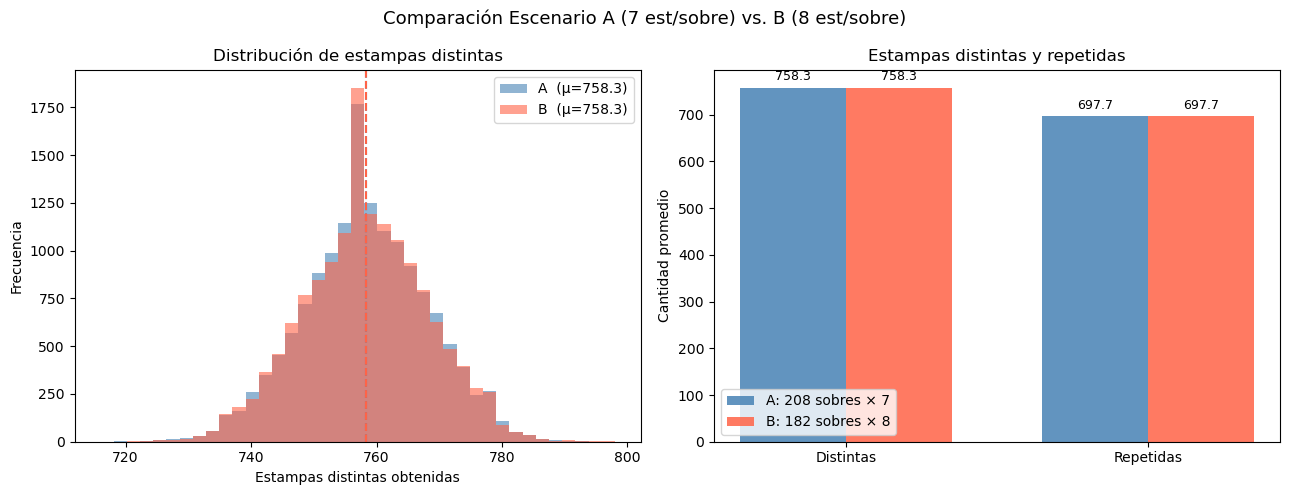

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Comparación Escenario A (7 est/sobre) vs. B (8 est/sobre)", fontsize=13)

# ── Gráfico 1: histogramas superpuestos de estampas distintas ─────────────────
ax = axes[0]
bins = np.linspace(
    min(distintas_A.min(), distintas_B.min()),
    max(distintas_A.max(), distintas_B.max()),
    40
)
ax.hist(distintas_A, bins=bins, alpha=0.6, label=f"A  (μ={distintas_A.mean():.1f})", color='steelblue')
ax.hist(distintas_B, bins=bins, alpha=0.6, label=f"B  (μ={distintas_B.mean():.1f})", color='tomato')
ax.axvline(distintas_A.mean(), color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(distintas_B.mean(), color='tomato',    linestyle='--', linewidth=1.5)
ax.set_xlabel("Estampas distintas obtenidas")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de estampas distintas")
ax.legend()

# ── Gráfico 2: barras lado a lado (distintas vs repetidas) ────────────────────
ax2 = axes[1]
categorias = ["Distintas", "Repetidas"]
prom_A = [distintas_A.mean(), repetidas_A.mean()]
prom_B = [distintas_B.mean(), repetidas_B.mean()]
x = np.arange(len(categorias))
w = 0.35
b1 = ax2.bar(x - w/2, prom_A, width=w, label="A: 208 sobres × 7", color='steelblue', alpha=0.85)
b2 = ax2.bar(x + w/2, prom_B, width=w, label="B: 182 sobres × 8", color='tomato',    alpha=0.85)
ax2.bar_label(b1, fmt='%.1f', padding=3, fontsize=9)
ax2.bar_label(b2, fmt='%.1f', padding=3, fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(categorias)
ax2.set_ylabel("Cantidad promedio")
ax2.set_title("Estampas distintas y repetidas")
ax2.legend()

plt.tight_layout()
plt.show()

## Tabla resumen comparativa

In [8]:
metricas = [
    ("Total estampas abiertas",      TOTAL_A,                    TOTAL_B),
    ("Media distintas",              f"{distintas_A.mean():.2f}", f"{distintas_B.mean():.2f}"),
    ("Desv. estándar distintas",     f"{distintas_A.std():.2f}",  f"{distintas_B.std():.2f}"),
    ("Media repetidas",              f"{repetidas_A.mean():.2f}", f"{repetidas_B.mean():.2f}"),
    ("% álbum completado",           f"{porcentaje_A.mean():.3f}%", f"{porcentaje_B.mean():.3f}%"),
    ("Valor p (prueba t)",           f"{p_valor:.4f}",            "—"),
]

print(f"{'Métrica':<35} {'Escenario A':>15} {'Escenario B':>15}")
print("─" * 67)
for m, a, b in metricas:
    print(f"{m:<35} {str(a):>15} {str(b):>15}")

Métrica                                 Escenario A     Escenario B
───────────────────────────────────────────────────────────────────
Total estampas abiertas                        1456            1456
Media distintas                              758.34          758.25
Desv. estándar distintas                       9.93            9.90
Media repetidas                              697.66          697.75
% álbum completado                          77.381%         77.373%
Valor p (prueba t)                           0.4667               —


## Conclusión

La simulación con R = 15,000 repeticiones confirma de forma contundente que **no existe diferencia práctica ni estadística** entre los dos esquemas.

**Resultado clave:** La diferencia en la media de estampas distintas entre B y A es de aproximadamente **−0.08 estampas** (es decir, prácticamente cero), y el intervalo de confianza al 95% para esa diferencia incluye el cero. El valor p de la prueba t de Welch es p ≈ 0.4667, muy por encima del umbral de 0.05.

**¿Por qué son equivalentes?**  
Dado que el muestreo de cada estampa es uniforme e independiente entre estampas (incluso dentro de un mismo sobre), el tamaño del paquete no altera la distribución del proceso. Lo único que importa es el total de estampas muestreadas (1,456 en ambos casos). Esto es consistente con la propiedad de que sumas de variables uniformes independientes con el mismo total tienen la misma distribución marginal para el número de valores únicos.

**Conclusión práctica:** Para el coleccionista, comprar 2 cajas (208 sobres × 7 estampas) o 182 sobres de 8 estampas produce el mismo resultado esperado: aproximadamente **77.4% del álbum** completado (≈ 758 estampas distintas de 980).